In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
# Load the diabetes dataset
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)

In [65]:
print(diabetes_X.shape, diabetes_y.shape)
print(diabetes_X[:5, :])
print(diabetes_y[:5])

(442, 10) (442,)
[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059
  -0.03603757  0.03430886  0.02268774 -0.00936191]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614
   0.00814208 -0.00259226 -0.03198764 -0.04664087]]
[151.  75. 141. 206. 135.]


In [9]:
db_diabetes = datasets.load_diabetes()
db_diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [23]:
print(db_diabetes.feature_names)
print(db_diabetes.data.shape)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
(442, 10)


In [24]:
db_diabetes.data[:5, :]

array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034],
       [-0.08906294, -0.04464164, -0.01159501, -0.03665608,  0.01219057,
         0.02499059, -0.03603757,  0.03430886,  0.02268774, -0.00936191],
       [ 0.00538306, -0.04464164, -0.03638469,  0.02187239,  0.00393485,
         0.01559614,  0.00814208, -0.00259226, -0.03198764, -0.04664087]])

In [25]:
# Use only one feature
X = diabetes_X[:, np.newaxis, 2]
print(X.shape)
print(X[:5])

(442, 1)
[[ 0.06169621]
 [-0.05147406]
 [ 0.04445121]
 [-0.01159501]
 [-0.03638469]]


In [45]:
# Split the data into training/testing sets
X_train = X[:-20]
X_test = X[-20:]
print(X_train.shape, X_test.shape)

(422, 1) (20, 1)


In [46]:
# Split the targets into training/testing sets
y_train = diabetes_y[:-20]
y_test = diabetes_y[-20:]
print(y_train.shape, y_test.shape)

(422,) (20,)


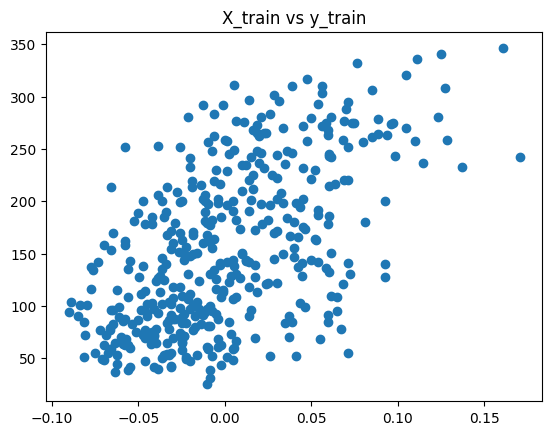

In [61]:
plt.scatter(X_train, y_train)
plt.title("X_train vs y_train")
plt.show()

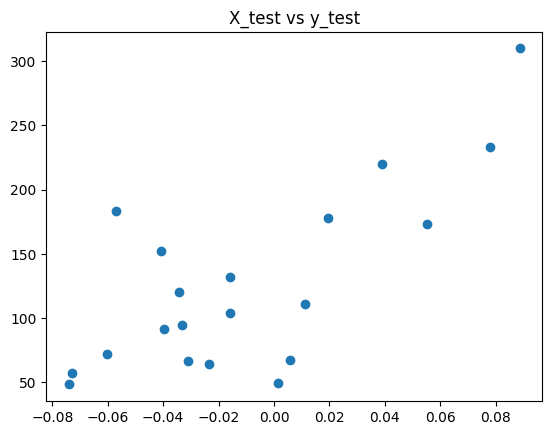

In [62]:
plt.scatter(X_test, y_test)
plt.title("X_test vs y_test")
plt.show()

In [47]:
# Create linear regression object
regr = linear_model.LinearRegression()
regr

LinearRegression()

In [48]:

# Train the model using the training sets
regr.fit(X_train, y_train)


LinearRegression()

In [49]:
# Make predictions using the testing set
y_pred = regr.predict(X_test)


In [50]:

# The coefficients
print("Coefficients: ", regr.coef_)
print("Intercept: ", regr.intercept_)
# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

Coefficients:  [938.23786125]
Intercept:  152.91886182616113
Mean squared error: 2548.07
Coefficient of determination: 0.47


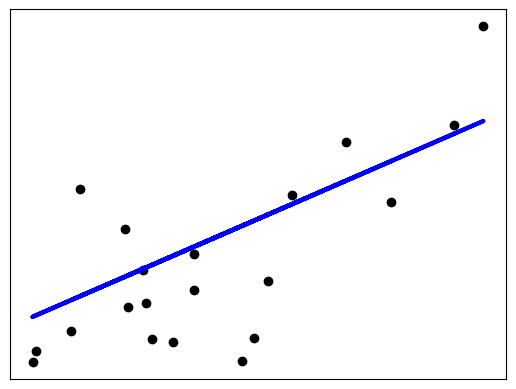

In [51]:
# Plot outputs
plt.scatter(X_test, y_test, color="black")
plt.plot(X_test, y_pred, color="blue", linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

In [57]:
yy_pred = regr.intercept_ + regr.coef_ * X_test

In [58]:
# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(y_test, yy_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, yy_pred))

Mean squared error: 2548.07
Coefficient of determination: 0.47


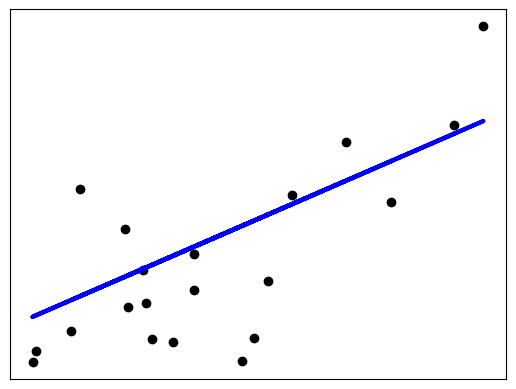

In [59]:
# Plot outputs
plt.scatter(X_test, y_test, color="black")
plt.plot(X_test, yy_pred, color="blue", linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()